In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, precision_recall_curve)
import xgboost as xgb

df = pd.read_csv('loan_data.csv')
print(df.shape)
print(df['not.fully.paid'].value_counts(normalize=True))

(9578, 14)
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


In [2]:
print(df.columns)

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')


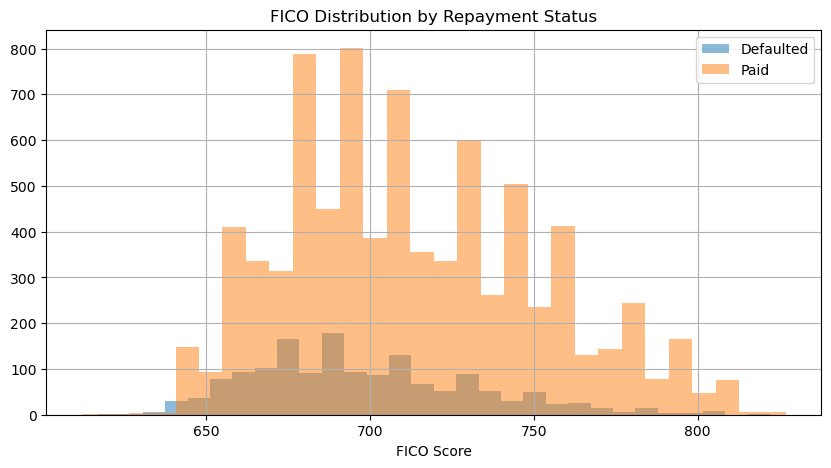

purpose
small_business        0.277868
educational           0.201166
home_improvement      0.170111
all_other             0.166023
debt_consolidation    0.152388
credit_card           0.115689
major_purchase        0.112128
Name: not.fully.paid, dtype: float64


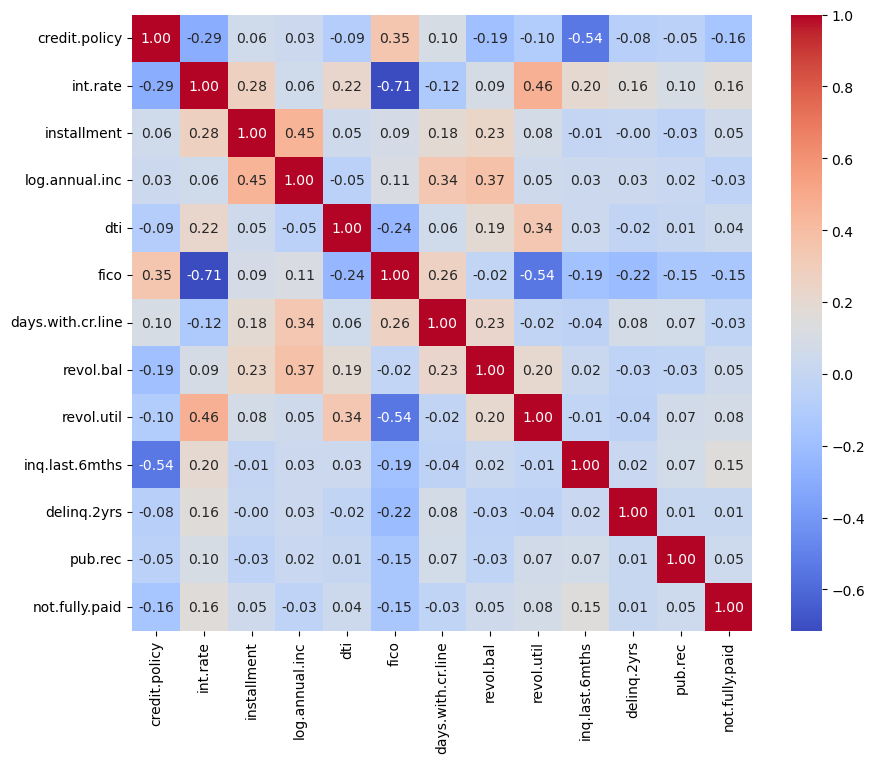

In [3]:
# FICO distribution by default status
plt.figure(figsize=(10, 5))
df[df['not.fully.paid'] == 1]['fico'].hist(alpha=0.5, bins=30, label='Defaulted')
df[df['not.fully.paid'] == 0]['fico'].hist(alpha=0.5, bins=30, label='Paid')
plt.legend(); plt.xlabel('FICO Score'); plt.title('FICO Distribution by Repayment Status')
plt.show()

# Default rate by purpose
purpose_default = df.groupby('purpose')['not.fully.paid'].mean().sort_values(ascending=False)
print(purpose_default)

# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [4]:
# One-hot encode purpose
df_model = pd.get_dummies(df, columns=['purpose'], drop_first=True)

X = df_model.drop('not.fully.paid', axis=1)
y = df_model['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = logreg.predict(X_test_scaled)

print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_proba_lr))
print(classification_report(y_test, y_pred_lr))

# Coefficients — interpretability is the whole point of using logit for credit scoring
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

Logistic Regression AUC: 0.6757380001972499
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      2012
           1       0.24      0.56      0.33       383

    accuracy                           0.64      2395
   macro avg       0.56      0.61      0.54      2395
weighted avg       0.78      0.64      0.69      2395

                       feature  coefficient
5                         fico    -0.297579
3               log.annual.inc    -0.257178
9               inq.last.6mths     0.242086
2                  installment     0.227515
12         purpose_credit_card    -0.183635
13  purpose_debt_consolidation    -0.146552
17      purpose_small_business     0.138234
16      purpose_major_purchase    -0.125981
0                credit.policy    -0.118960
8                   revol.util     0.116663
7                    revol.bal     0.112711
1                     int.rate     0.083752
11                     pub.rec     0.052958
6            

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

XGBoost AUC: 0.6399046971435097
                       feature  importance
0                credit.policy    0.326739
1                     int.rate    0.077093
17      purpose_small_business    0.069503
9               inq.last.6mths    0.059765
5                         fico    0.040656
8                   revol.util    0.040642
12         purpose_credit_card    0.038206
13  purpose_debt_consolidation    0.037671
3               log.annual.inc    0.035988
2                  installment    0.035820
6            days.with.cr.line    0.035694
4                          dti    0.034681
7                    revol.bal    0.032645
16      purpose_major_purchase    0.031231
15    purpose_home_improvement    0.029819
14         purpose_educational    0.026711
11                     pub.rec    0.025359
10                 delinq.2yrs    0.021777


### Credit Risk Evaluation: ROC, KS Statistic, Gains/Lift Chart

Logistic Regression KS: 0.2402
XGBoost KS: 0.1969


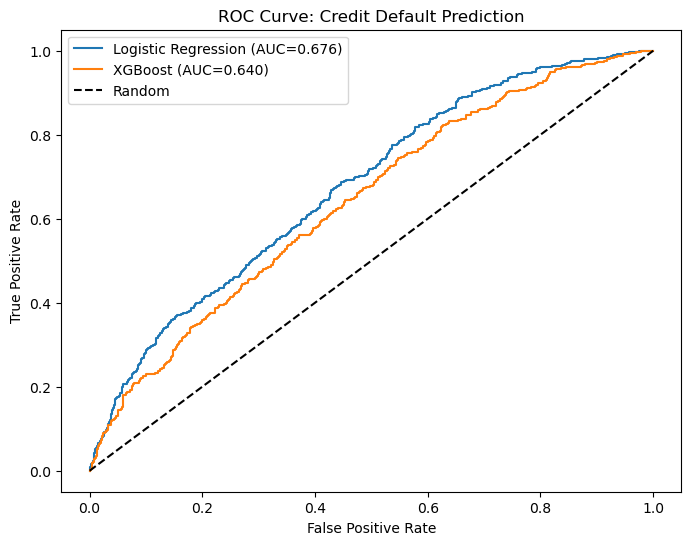

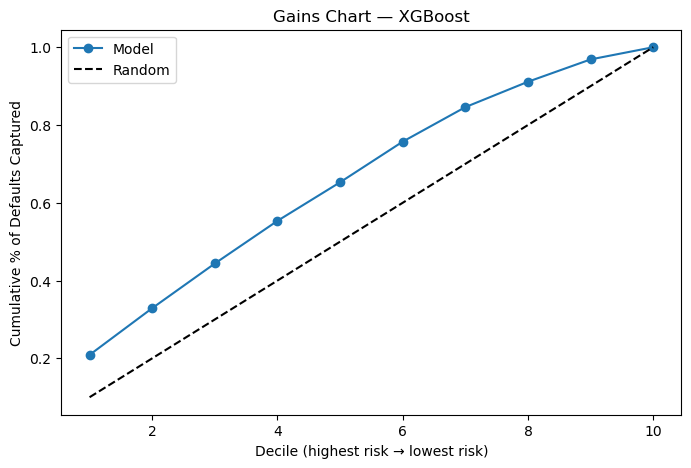

In [7]:
def ks_statistic(y_true, y_proba):
    """KS statistic — the standard credit risk separation metric."""
    df_ks = pd.DataFrame({'y': y_true, 'proba': y_proba})
    df_ks = df_ks.sort_values('proba', ascending=False).reset_index(drop=True)
    df_ks['cum_bad'] = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    df_ks['ks'] = df_ks['cum_bad'] - df_ks['cum_good']
    return df_ks['ks'].max(), df_ks

ks_lr, ks_df_lr = ks_statistic(y_test.values, y_pred_proba_lr)
ks_xgb, ks_df_xgb = ks_statistic(y_test.values, y_pred_proba_xgb)
print(f"Logistic Regression KS: {ks_lr:.4f}")
print(f"XGBoost KS: {ks_xgb:.4f}")

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_pred_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Credit Default Prediction')
plt.legend(); plt.show()

# Gains/Lift chart
def gains_chart(y_true, y_proba, n_bins=10):
    df_g = pd.DataFrame({'y': y_true, 'proba': y_proba})
    df_g = df_g.sort_values('proba', ascending=False).reset_index(drop=True)
    df_g['decile'] = pd.qcut(df_g.index, n_bins, labels=False)
    gains = df_g.groupby('decile')['y'].agg(['sum', 'count'])
    gains['cum_bad_rate'] = gains['sum'].cumsum() / gains['sum'].sum()
    return gains

gains = gains_chart(y_test.values, y_pred_proba_xgb)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), gains['cum_bad_rate'], marker='o', label='Model')
plt.plot([1, 10], [0.1, 1.0], 'k--', label='Random')
plt.xlabel('Decile (highest risk → lowest risk)')
plt.ylabel('Cumulative % of Defaults Captured')
plt.title('Gains Chart — XGBoost')
plt.legend(); plt.show()

### Credit Scorecard

In [17]:
def proba_to_score(proba, base_score=600, base_odds=50, pdo=20):
    """Standard credit scorecard scaling: points-to-double-odds."""
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    odds = (1 - proba) / proba
    score = offset + factor * np.log(odds)
    return score

test_scores = proba_to_score(y_pred_proba_lr)
score_df = pd.DataFrame({'score': test_scores, 'actual_default': y_test.values})
score_df['risk_grade'] = pd.cut(score_df['score'], bins=5,
                                 labels=['E (highest risk)', 'D', 'C', 'B', 'A (lowest risk)'])
score_df.groupby('risk_grade', observed=True)['score'].agg(['min','max', 'mean', 'count'])

,min,max,mean,count
risk_grade,,,,
E (highest risk),374.852251,398.036247,384.417832,3
D,415.404651,449.697138,437.443009,66
C,450.187032,487.703377,475.076449,865
B,487.744470,525.226979,502.536236,1359
A (lowest risk),525.425996,562.976516,533.083048,102


In [18]:
print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_proba_lr))
print("XGBoost AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
ks_lr, ks_df_lr = ks_statistic(y_test.values, y_pred_proba_lr)
ks_xgb, ks_df_xgb = ks_statistic(y_test.values, y_pred_proba_xgb)
print(f"Logistic Regression KS: {ks_lr:.4f}")
print(f"XGBoost KS: {ks_xgb:.4f}")

Logistic Regression AUC: 0.6757380001972499
XGBoost AUC: 0.6399046971435097
Logistic Regression KS: 0.2402
XGBoost KS: 0.1969
